In [ ]:
import os
import json
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [ ]:
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
result_save_path = os.path.join(parent_dir, "data", 'result_figs')

training_log_path = os.path.join(parent_dir, 
                                 'data/training_logs/Mid/sim2real_kps_Mid_contact_Time_50s_Max_Epochs_1000_Optimized_Damping_Amplification_Youngs_Modulus/log.json')
OPTIMIZE_SUBJECT = ["Youngs_Modulus", "Applied_Force", "Force_Amplification", "Damping_Amplification"]
OPTPARAMS = [OPTIMIZE_SUBJECT[3], OPTIMIZE_SUBJECT[0]]
num_colors = 5

cmap = plt.get_cmap("viridis")  # tab10, tab20, viridis, plasma...

COLORMAP = cmap(np.linspace(0.1, 0.9, num_colors))

# Function libs

## utils

In [ ]:
def load_training_log(log_path, opt_param=OPTPARAMS):
    with open(log_path, 'r') as f:
        data = json.load(f)
    optimized_parameters = []
    for i in opt_param:
        if i == "Youngs_Modulus":
            optimized_parameters.append(np.array(data["Youngs_Modulus_log"]))  
            continue
        optimized_parameters.append(np.array(data[i]))
         
    total_loss = np.array(data["total_loss"])
    avg_loss = np.array(data["avg_loss"])
    
    return optimized_parameters, total_loss, avg_loss

In [ ]:
def load_final_stage(path, opt_param=OPTPARAMS):
    trajectories = np.load(path)["position"][-1]
    parameters = []
    for param in opt_param:
        parameters.append(np.load(path)[param])
    return trajectories, parameters

In [ ]:
def set_axes_equal(ax):
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = x_limits[1] - x_limits[0]
    y_range = y_limits[1] - y_limits[0]
    z_range = z_limits[1] - z_limits[0]

    max_range = max(x_range, y_range, z_range)

    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)

    ax.set_xlim3d([x_middle - max_range/2, x_middle + max_range/2])
    ax.set_ylim3d([y_middle - max_range/2, y_middle + max_range/2])
    ax.set_zlim3d([z_middle - max_range/2, z_middle + max_range/2])

## main funcs

In [ ]:
def point_cloud_visual(initial_path,
                       target_path, 
                       optimized_path, 
                       opt_param, 
                       fig_size=(10, 10),
                       save_flag=False,
                       save_name="single_liver",
                       save_path=None
                       ):
    target, target_params = load_final_stage(target_path, opt_param=opt_param)
    initial, initial_params = load_final_stage(initial_path, opt_param=opt_param)
    optimized, optimized_params = load_final_stage(optimized_path, opt_param=opt_param)

    fig = plt.figure(figsize=fig_size)
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(initial[:, 0], initial[:, 1], initial[:, 2], s=1, c='blue', label=f'Initial: {int(initial_params)}')
    ax.scatter(target[:, 0], target[:, 1], target[:, 2], s=10, c='black', label=f'Target: {int(target_params)}')
    ax.scatter(optimized[:, 0], optimized[:, 1], optimized[:, 2], s=1, c='red', label=f'Optimized: {int(optimized_params)}')
    set_axes_equal(ax)
    ax.view_init(elev=10, azim=95)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    
    if save_flag:
        if save_path is None:
            print('Save path not specified, using default.')
            fig.savefig(f"{save_name}.pdf", dpi=300, bbox_inches='tight')
        else:
            fig.savefig(f"{save_path}/{save_name}.pdf", dpi=300, bbox_inches='tight')

    plt.show()

In [ ]:
def loss_param_visualization(log_path,
                             target_path = None,
                             target_param = None,
                             opt_param=OPTPARAMS,
                             optimizing_method = None,
                             loss_type="total loss",
                             loss_plot_type="line",
                             save_flag=False,
                             save_name="loss",
                             save_path=None):
    
    optimized_parameters, total_loss, avg_loss = load_training_log(log_path, opt_param=opt_param)
    param_max = max([max(param) for param in optimized_parameters])

    x = np.arange(len(avg_loss))  # iteration / step

    # Left axis: optimized_parameters
    if optimizing_method is None:
        for i in range(len(opt_param)):
            fig, ax = plt.subplots(figsize=(10, 5))
            if opt_param[i] == "Youngs_Modulus":
                data_label = f'{opt_param[i]} log'
            else:
                data_label = f'{opt_param[i]}'
            ax.plot(x, optimized_parameters[i], color=COLORMAP[i], label=data_label)
            ax.scatter(x, optimized_parameters[i], color=COLORMAP[i], s=50, marker='x')
            ax.set_xlabel('Epoch')
            ax.set_ylabel(f'{opt_param[i]}', color='b')
            ax.set_xlim(0, len(avg_loss))
            # ax.set_ylim(0, max(optimized_parameters[i]) * 1.05)
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))
            ax.legend()
            plt.show()

    elif optimizing_method == "alternating":
        for i in range(len(opt_param)):
            fig, ax = plt.subplots(figsize=(10, 5))
            if opt_param[i] == "Youngs_Modulus":
                data_label = f'{opt_param[i]} log'
            else:
                data_label = f'{opt_param[i]}'

            # f = interp1d(

            #     x[i::len(opt_param)],

            #     optimized_parameters[i],

            #     kind="previous",

            #     bounds_error=False,

            #     fill_value=(optimized_parameters[i][0], optimized_parameters[i][-1])
            #     )
            # opt_para_full = f(x)
            ax.step(x, optimized_parameters[i], where='post', linewidth=2, color=COLORMAP[i], label=data_label)
            ax.scatter(x, optimized_parameters[i], color=COLORMAP[i], s=10, marker='x')
            if target_param is not None:
                ax.axhline(y=target_param[i], color='black', linewidth=2, linestyle='--', label=f'Start {data_label}')
                
            ax.set_xlabel('Epoch')
            ax.set_ylabel(f'{opt_param[i]}')
            ax.set_xlim(0, len(avg_loss)-0.9)
            # ax.set_ylim(top = max(optimized_parameters[i]) * 1.05)
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))
            ax.legend()
            plt.show()

    if target_path is not None:
        __, gt_param = load_final_stage(target_path, opt_param=opt_param)
        ax.axhline(y=gt_param, color='black', linewidth=2, linestyle='--', label=f'Target {opt_param}')

    fig, ax = plt.subplots(figsize=(10, 5))
    # Right axis: total_loss
    if loss_type == "total loss":
        if loss_plot_type == "line":
            ax.plot(x, total_loss, color='r', linewidth=2, label='Total Loss')
            y_scale = 1.05
            # y_min = min(total_loss) * 0.95 if min(total_loss) > 0 else min(total_loss) * 1.05
            y_min = 0.
        elif loss_plot_type == "semilogy":
            ax.semilogy(x, total_loss, color='r', linewidth=2, label='Total Loss')
            y_scale = 5.
            y_min = 1.e-2
        ax.scatter(x, total_loss, color='r', s=30, marker='x', label='Total Loss (step)')
        ax.set_ylabel('Total Loss')
        ax.tick_params(axis='y')
        ax.set_ylim(y_min, max(total_loss)*y_scale)
    elif loss_type == "avg loss":
        if loss_plot_type == "line":
            ax.plot(x, avg_loss, color='r', linewidth=2, label='Average Loss')
            y_scale = 1.05
            # y_min = min(avg_loss) * 0.95 if min(avg_loss) > 0 else min(avg_loss) * 1.05
            y_min = 0.
        elif loss_plot_type == "semilogy":
            ax.semilogy(x, avg_loss, color='r', linewidth=2, label='Average Loss')
            y_scale = 5.
            y_min = 1.e-2
        ax.scatter(x, avg_loss, color='r', s=10, marker='x')
        ax.set_ylabel('Average Loss')
        ax.tick_params(axis='y')
        ax.set_ylim(y_min, max(avg_loss)*y_scale)
    
    ax.set_xlabel('Epoch')
    ax.set_xlim(0, len(avg_loss)-0.9)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend()
    plt.show()

    if save_flag:
        if save_path is None:
            print('Save path not specified, using default.')
            fig.savefig(f"{save_name}.pdf", dpi=300, bbox_inches='tight')
        else:
            fig.savefig(f"{save_path}/{save_name}.pdf", dpi=300, bbox_inches='tight')



# Visualization

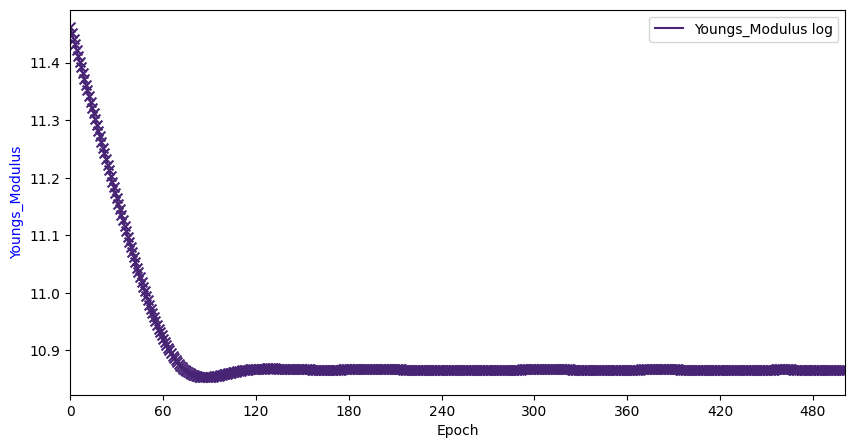

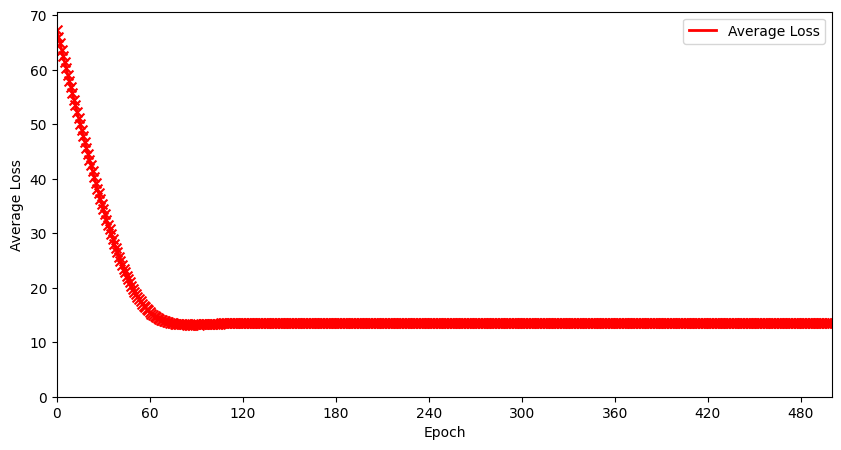

In [ ]:
loss_param_visualization(training_log_path, 
                         target_param = [1.0, np.log(9500.e3)],
                         opt_param=OPTPARAMS,
                         optimizing_method="alternating",
                         loss_type="avg loss",
                         loss_plot_type="line",
                         save_flag=False,
                         save_name="twin_Modulus_loss",
                         save_path=result_save_path)